# First steps - Exercise

Explore the system we set up before. See what happens to the concentration over time at the outlet, as you increase or decrease certain parameters, such as the flow rate or the column dimensions.

(<Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='$time~/~min$', ylabel='$c~/~mM$'>)

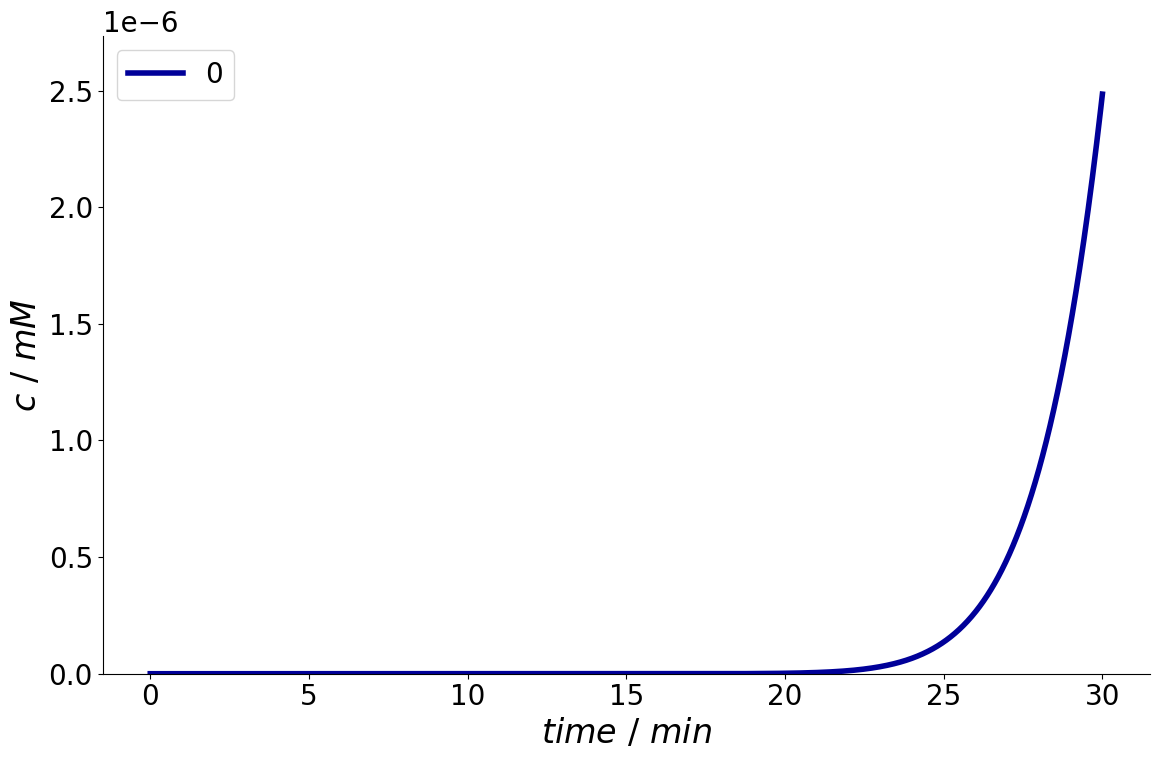

In [ ]:
from CADETProcess.processModel import ComponentSystem

component_system = ComponentSystem(1)

from CADETProcess.processModel import Inlet

inlet = Inlet(component_system, "inlet")
inlet.c = 1  # mol / m^3
inlet.flow_rate = 1e-7

from CADETProcess.processModel import Outlet
outlet = Outlet(component_system, "outlet")

from CADETProcess.processModel import LumpedRateModelWithoutPores

column = LumpedRateModelWithoutPores(component_system, "column")
column.total_porosity = 0.4
column.diameter = 0.2
column.length = 0.1
column.axial_dispersion = 1e-7

from CADETProcess.processModel import FlowSheet

flow_sheet = FlowSheet(component_system, "flow_sheet")

flow_sheet.add_unit(inlet)
flow_sheet.add_unit(outlet)
flow_sheet.add_unit(column)

flow_sheet.add_connection(inlet, column)
flow_sheet.add_connection(column, outlet)

from CADETProcess.processModel import Process
process = Process(flow_sheet, "process")
process.cycle_time = 30*60

from CADETProcess.simulator import Cadet

simulator = Cadet()

simulation_results = simulator.simulate(process)

simulation_results.solution.outlet.outlet.plot()

In the next exercise, try setting up a system with two LRM columns connected in series.

(<Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='$time~/~min$', ylabel='$c~/~mM$'>)

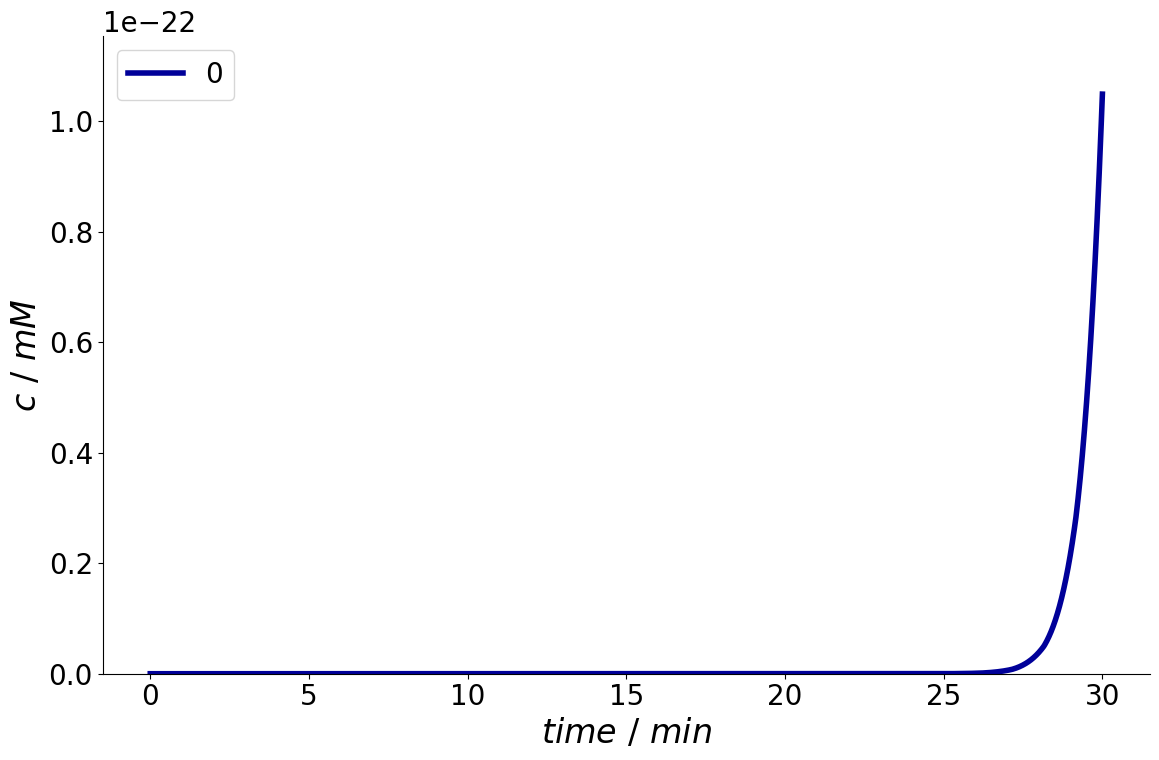

In [2]:
from CADETProcess.processModel import ComponentSystem

component_system = ComponentSystem(1)

from CADETProcess.processModel import Inlet

inlet = Inlet(component_system, "inlet")
inlet.c = 1  # mol / m^3
inlet.flow_rate = 1e-7

from CADETProcess.processModel import Outlet
outlet = Outlet(component_system, "outlet")

from CADETProcess.processModel import LumpedRateModelWithoutPores

column = LumpedRateModelWithoutPores(component_system, "column")
column.total_porosity = 0.4
column.diameter = 0.2
column.length = 0.1
column.axial_dispersion = 1e-7

column2 = LumpedRateModelWithoutPores(component_system, "column2")
column2.total_porosity = 0.4
column2.diameter = 0.2
column2.length = 0.1
column2.axial_dispersion = 1e-7


from CADETProcess.processModel import FlowSheet

flow_sheet = FlowSheet(component_system, "flow_sheet")

flow_sheet.add_unit(inlet)
flow_sheet.add_unit(outlet)
flow_sheet.add_unit(column)
flow_sheet.add_unit(column2)

flow_sheet.add_connection(inlet, column)
flow_sheet.add_connection(column, column2)
flow_sheet.add_connection(column2, outlet)

from CADETProcess.processModel import Process
process = Process(flow_sheet, "process")
process.cycle_time = 30*60

from CADETProcess.simulator import Cadet

simulator = Cadet()

simulation_results = simulator.simulate(process)

simulation_results.solution.outlet.outlet.plot()